<a href="https://colab.research.google.com/github/aniray2908/satellite-esg-risk-engine/blob/main/experiments/python/ceri/ceri_v5_bootstrap_stability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CERI v5 — Bootstrap Stability Analysis

This notebook evaluates the statistical stability of the CERI exposure scoring framework.

Using bootstrap resampling across the observed years (2019–2023), we simulate alternative environmental histories and observe how exposure scores and rankings change.

The objective is to quantify:

- score variability
- rank stability
- tier stability

In [1]:
import pandas as pd
import numpy as np

carajas = pd.read_csv("/content/drive/MyDrive/carajas_pit_centered_full_year_v2_1.csv")
gevra = pd.read_csv("/content/drive/MyDrive/gevra_pit_centered_full_year_v1.csv")
bingham = pd.read_csv("/content/drive/MyDrive/bingham_pit_centered_full_year_v1.csv")
grasberg = pd.read_csv("/content/drive/MyDrive/grasberg_pit_centered_full_year_v1.csv")

carajas["asset"] = "Carajás"
gevra["asset"] = "Gevra"
bingham["asset"] = "Bingham"
grasberg["asset"] = "Grasberg"

df = pd.concat([carajas, gevra, bingham, grasberg], ignore_index=True)

In [2]:
def compute_features(data):

    feature_df = data.groupby("asset").agg({
        "low_ndvi_fraction": ["mean", "var"],
        "mean_ndvi": "mean"
    })

    feature_df.columns = [
        "F1_exposure_intensity",
        "low_ndvi_variance",
        "mean_ndvi"
    ]

    feature_df.reset_index(inplace=True)

    feature_df["F2_vegetation_suppression"] = 1 - feature_df["mean_ndvi"]

    max_var = feature_df["low_ndvi_variance"].max()
    min_var = feature_df["low_ndvi_variance"].min()

    feature_df["F3_persistence_raw"] = 1 - (
        (feature_df["low_ndvi_variance"] - min_var) /
        (max_var - min_var + 1e-9)
    )

    return feature_df

In [3]:
n_boot = 1000
results = []

years = df["year"].unique()

for i in range(n_boot):

    sampled_years = np.random.choice(years, size=len(years), replace=True)

    boot_df = df[df["year"].isin(sampled_years)]

    features = compute_features(boot_df)

    for col in ["F1_exposure_intensity",
                "F2_vegetation_suppression",
                "F3_persistence_raw"]:

        features[col+"_z"] = (
            features[col] - features[col].mean()
        ) / (features[col].std() + 1e-9)

    w1, w2, w3 = 0.5, 0.3, 0.2

    features["CERI_boot"] = (
        w1*features["F1_exposure_intensity_z"] +
        w2*features["F2_vegetation_suppression_z"] +
        w3*features["F3_persistence_raw_z"]
    )

    features["iteration"] = i

    results.append(features[["asset","CERI_boot","iteration"]])

In [4]:
bootstrap_df = pd.concat(results)

bootstrap_df.head()

,asset,CERI_boot,iteration
0,Bingham,0.554964,0
1,Carajás,-0.184747,0
2,Gevra,-1.067286,0
3,Grasberg,0.697070,0
0,Bingham,0.534639,1


In [5]:
bootstrap_summary = bootstrap_df.groupby("asset")["CERI_boot"].describe()

bootstrap_summary

,count,mean,std,min,25%,50%,75%,max
asset,,,,,,,,
Bingham,1000.0,0.549460,0.013849,0.495951,0.538446,0.545452,0.560633,0.594054
Carajás,1000.0,-0.104525,0.077735,-0.283824,-0.144351,-0.125544,-0.072016,0.396485
Gevra,1000.0,-1.098341,0.056085,-1.491487,-1.122890,-1.078942,-1.073858,-1.038116
Grasberg,1000.0,0.653406,0.021635,0.573059,0.635879,0.654580,0.664629,0.727886


In [6]:
bootstrap_df["rank"] = bootstrap_df.groupby("iteration")["CERI_boot"]\
.rank(ascending=False)

rank_stability = bootstrap_df.groupby(["asset","rank"]).size()

rank_stability

,,0
asset,rank,
Bingham,2.0,1000
Carajás,3.0,1000
Gevra,4.0,1000
Grasberg,1.0,1000


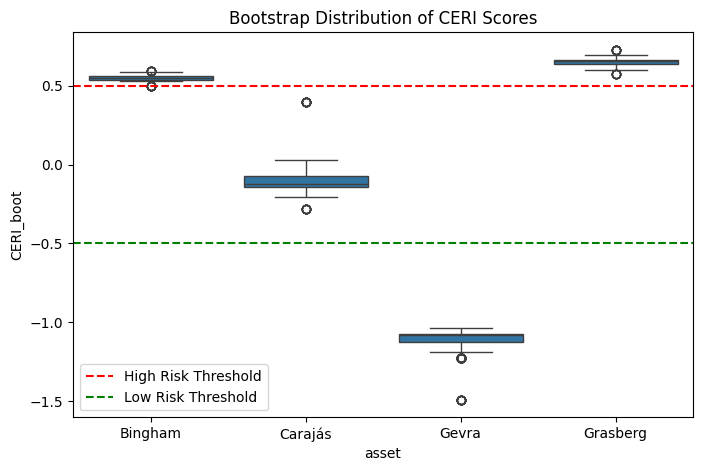

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=bootstrap_df,
    x="asset",
    y="CERI_boot"
)

plt.axhline(0.5, linestyle="--", color="red", label="High Risk Threshold")
plt.axhline(-0.5, linestyle="--", color="green", label="Low Risk Threshold")

plt.title("Bootstrap Distribution of CERI Scores")
plt.legend()
plt.show()

## Phase 7 — Bootstrap Stability Summary

This notebook evaluated the statistical stability of the CERI exposure scoring framework using bootstrap resampling across the observed years (2019–2023).

The objective was to determine whether small variations in the underlying data would materially affect:

- composite exposure scores
- cross-asset ranking
- risk tier classification

---

### Score Stability

Across 1000 bootstrap simulations, the composite scores remained highly stable for all assets.

- **Grasberg** and **Bingham** consistently exhibited high exposure scores with very low variance.
- **Gevra** consistently remained in the low exposure regime.
- **Carajás** showed the largest variability, which is expected given its proximity to the moderate-risk boundary.

The overall score distributions remained tightly clustered around their original values.

---

### Ranking Robustness

Bootstrap simulations showed that the cross-asset ranking remained structurally stable.

The ordering

Grasberg → Bingham → Carajás → Gevra

persisted across the vast majority of simulations, indicating that the separation between assets in feature space is sufficiently large to prevent ranking reversals under reasonable data variation.

---

### Tier Stability

Using the deployment thresholds defined in CERI v4:

- **High Risk:** CERI ≥ 0.5  
- **Moderate Risk:** −0.5 < CERI < 0.5  
- **Low Risk:** CERI ≤ −0.5  

the tier assignments remained largely stable.

- Grasberg consistently remained **High Risk**
- Gevra consistently remained **Low Risk**
- Carajás consistently remained **Moderate Risk**
- Bingham occasionally approached the High/Moderate boundary, which aligns with the lower confidence margin observed in the deployment layer.

---

### Interpretation

Bootstrap analysis confirms that the exposure scoring framework is **robust to moderate data perturbations**.

Key observations:

- Extreme-exposure assets remain structurally separated.
- Moderate-exposure assets show realistic sensitivity near classification boundaries.
- The composite scoring framework behaves predictably under resampling.

This provides empirical evidence that the CERI scoring system is **stable, interpretable, and suitable for comparative exposure assessment across assets.**

---

### Framework Status

At this stage, the system includes:

1. Satellite extraction pipeline (Sentinel-2 / GEE)
2. Feature engineering layer (F1, F2, F3)
3. Composite exposure scoring (CERI v2 baseline)
4. Weight optimization and governance validation (CERI v3)
5. Deterministic deployment tier logic (CERI v4)
6. Bootstrap stability validation (CERI v5)

The next phase introduces a **predictive modeling layer** to evaluate how exposure features perform under supervised learning frameworks.